### 회귀모형의 가정 체크

다중선형회귀모델을 돌린 후 잔차에 대해 판단 진행 (시각 / test)

- 선형성
- 독립성
- 등분산성
- 정규성

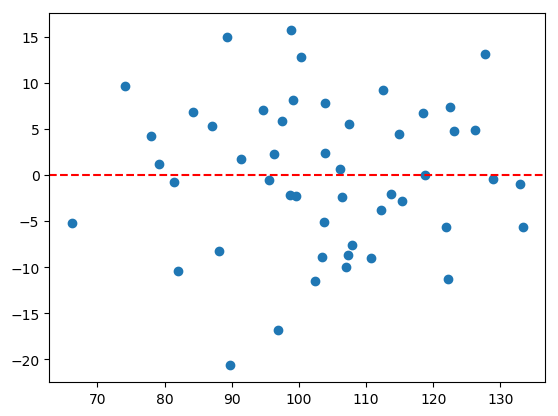

,Value
Lagrange multiplier statistic,1.049248
"p-value (0.05 미만이면 null 기각, 이분산성 존재)",0.305680
f-value,1.028869
f p-value,0.315510


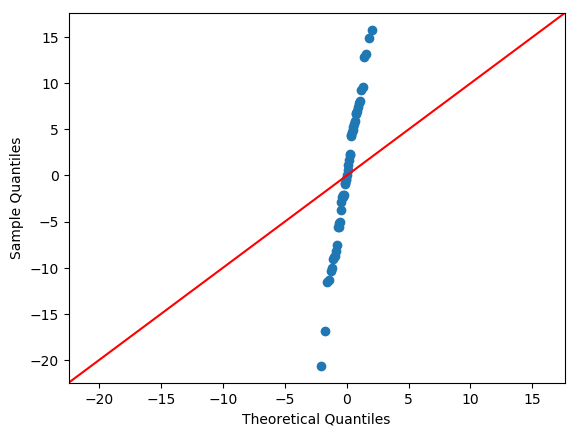

In [ ]:
# 독립변수와 종속변수 간의 선형성이 존재하는지 시각화 or 다중선형회귀모델링 후 잔차와 예측값의 scatter의 수평정도 확인
import numpy as np; import pandas as pd; import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.datasets import make_regression
X, y, w = make_regression(n_samples=50, n_features=1, bias=100, noise=10, coef=True, random_state=0)


if '선형성':

    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    predictions = model.predict(X)
    residuals = model.resid #잔차

    plt.scatter(predictions, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.show()



if '독립성, Durbin-Watson 통계량':
    # from statsmodels.stats.stattools import durbin_watson 

    sm.stats.durbin_watson(model.resid) # 독립이 아니다. 0~4사이값을 가지며 2에 가까울수록 자기상관이 없음(독립)을 의미



if '등분산성, Breusch-Pagan 테스트 , 귀무가설 (H0): 잔차의 분산이 일정하다':
    # from statsmodels.stats.diagnostic import het_breuschpagan

    result_bp = sm.stats.het_breuschpagan(model.resid, X) #p-value
    display(pd.DataFrame(result_bp, index=['Lagrange multiplier statistic', 'p-value (0.05 미만이면 null 기각, 이분산성 존재)', 'f-value', 'f p-value'], columns=['Value']))



if '정규성, Shapiro-Wilk 테스트와 Q-Q 플롯, 귀무가설 : 정규성을 따른다':

    from scipy.stats import shapiro
    st, p = shapiro(model.resid)

    # from statsmodels.graphics.gofplots import qqplot

    sm.graphics.qqplot(model.resid, line='45')
    plt.show()


### 다중 회귀

```python
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.coef_ # 회귀계수
lr.intercept_ # 절편


import statsmodels.api as sm

X = sm.add_constant(X) # 상수추가 필수
model = sm.OLS(y, X).fit()
display(model.summary()) # model.summary().tables[0] ,model.summary().tables[1] 따로 출력가능

model.rsquared #결정계수
model.rsquared_adj # 수정된 결정계수


```

### 교호작용 유무에 다른 회귀모형
두 개 이상의 변수가 종속 변수에 미치는 효과가 서로에 의해 변화될 수 있음을 나타냄. 즉, 한 변수의 효과가 다른 변수의 수준에 따라 달라진다는 것을 의미
확인하고 싶은 교호작용 항들을 묶어서 모델을 돌려보고 p값을 통해 해당 변수의 유의성을 파악한다     


```python
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# 가상의 데이터 생성
np.random.seed(0)
data = pd.DataFrame({
    'X1': np.random.normal(size=100),
    'X2': np.random.normal(size=100),
    'Z': np.random.normal(size=100)  # Z는 교호작용을 확인하기 위한 변수
})

# 종속 변수 생성 (X1, X2의 영향과 X1과 X2의 교호작용을 포함)
data['Y'] = 2 + 3*data['X1'] + 2*data['X2'] + 1.5*data['X1']*data['X2'] + data['Z']

# 교호작용을 포함한 회귀모형 적합
model = smf.ols('Y ~ X1 + X2 + X1:X2', data=data).fit()  # X1:X2는 X1과 X2의 교호작용 항

# 결과 요약 출력
print(model.summary())
```

### 푸아송회귀
응답 변수가 카운트 데이터(예: 어떤 시간 동안 발생하는 이벤트의 횟수)일 때 사용되는 회귀 모델

```python
import numpy as np
import statsmodels.api as sm

# 임의의 데이터 생성
np.random.seed(10)
n_samples = 100
X = np.random.normal(size=(n_samples, 2))
X = sm.add_constant(X)  # 상수항 추가
beta = [0.1, 0.3, -0.2]  # 실제 파라미터
y_true = np.dot(X, beta)
y = np.random.poisson(np.exp(y_true))  # 푸아송 분포에서 샘플링

# 푸아송 회귀 모델 적합
model = sm.GLM(y, X, family=sm.families.Poisson()).fit()

# 결과 출력
print(model.summary())
```

In [5]:
from IPython.display import display
from IPython.display import Image, Latex
import pandas as pd

# 1. 데이터프레임 출력
df = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
display(df)  # HTML 테이블 형식으로 렌더링

# 2. 이미지 출력
# display(Image(filename='path/to/image.png'))

# 3. 수식 출력 (LaTeX)
display(Latex(r'$x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$'))

,A,B
0,1,3
1,2,4


<IPython.core.display.Latex object>